# Dataset Comparison: Our GitHub-Agentic-PR-Dataset vs AIDev

This notebook presents a **clear, apple-to-apple comparison** between two agentic PR datasets:

| | **Our Dataset** | **AIDev** |
|---|---|---|
| **Source** | `mabujadallah/GitHub-Agentic-PR-Dataset` | `hao-li/AIDev` |
| **Agents** | Copilot, Cursor, Claude Code, Devin | Copilot, Cursor, Claude Code, Devin, ~~Codex~~ |

**Match strategy**: PRs are matched on `repo_name + PR number` (AIDev uses GraphQL node IDs, we use REST API IDs).  
**Scope**: Same repositories, same time range, Codex excluded from AIDev.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from huggingface_hub import hf_hub_download
from IPython.display import display, Markdown, HTML

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# ── Color palette ──
C_OURS    = '#2196F3'   # blue
C_OVERLAP = '#4CAF50'   # green
C_AIDEV   = '#FF9800'   # orange
C_MISS    = '#E53935'   # red

## 1. Load & Prepare Data

In [27]:
# ── Load agent PR datasets ──
ours = pd.read_parquet(hf_hub_download(
    repo_id="mabujadallah/GitHub-Agentic-PR-Dataset",
    filename="all_pull_requests.parquet", repo_type="dataset"))

aidev = pd.read_parquet(hf_hub_download(
    repo_id="hao-li/AIDev",
    filename="all_pull_request.parquet", repo_type="dataset"))

# ── Load human PR datasets ──
ours_human = pd.read_parquet(hf_hub_download(
    repo_id="mabujadallah/GitHub-Agentic-PR-Dataset",
    filename="human_pull_requests.parquet", repo_type="dataset"))

aidev_human = pd.read_parquet(hf_hub_download(
    repo_id="hao-li/AIDev",
    filename="human_pull_request.parquet", repo_type="dataset"))

print(f"Loaded  Our agent PRs:   {len(ours):>10,}")
print(f"Loaded  AIDev agent PRs: {len(aidev):>10,}")
print(f"Loaded  Our human PRs:   {len(ours_human):>10,}")
print(f"Loaded  AIDev human PRs: {len(aidev_human):>10,}")

Loaded  Our agent PRs:    1,959,649
Loaded  AIDev agent PRs:    932,791
Loaded  Our human PRs:    1,186,136
Loaded  AIDev human PRs:      6,618


In [28]:
# ── Remove Codex (not in our scope) ──
codex_count = (aidev["agent"] == "OpenAI_Codex").sum()
aidev = aidev[aidev["agent"] != "OpenAI_Codex"].reset_index(drop=True)

# ── Normalize repo names ──
for df in [ours, aidev, ours_human, aidev_human]:
    if "repo_name" not in df.columns and "repo_url" in df.columns:
        df["repo_name"] = df["repo_url"].str.replace(
            "https://api.github.com/repos/", "", regex=False)
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

# ── Build match keys ──
for df in [ours, aidev, ours_human, aidev_human]:
    df["match_key"] = df["repo_name"] + "#" + df["number"].astype(str)

print(f"Removed {codex_count:,} OpenAI Codex PRs from AIDev")
print(f"AIDev agents remaining: {sorted(aidev['agent'].unique())}")

Removed 814,522 OpenAI Codex PRs from AIDev
AIDev agents remaining: ['Claude_Code', 'Copilot', 'Cursor', 'Devin']


## 2. Dataset Overview

A high-level comparison of both datasets **before** any filtering.

In [29]:
ours_repos = set(ours["repo_name"].unique())
aidev_repos = set(aidev["repo_name"].unique())
shared_repos = ours_repos & aidev_repos

overview = pd.DataFrame({
    "Metric": ["Agent PRs", "Human PRs", "Repositories", "Agents", "Time Range"],
    "Our Dataset": [
        f"{len(ours):,}",
        f"{len(ours_human):,}",
        f"{len(ours_repos):,}",
        ", ".join(sorted(set(ours['agent'].unique()) - {'human'})),
        f"{ours['created_at'].min().strftime('%Y-%m-%d')}  to  {ours['created_at'].max().strftime('%Y-%m-%d')}"
    ],
    "AIDev (no Codex)": [
        f"{len(aidev):,}",
        f"{len(aidev_human):,}",
        f"{len(aidev_repos):,}",
        ", ".join(sorted(aidev['agent'].unique())),
        f"{aidev['created_at'].min().strftime('%Y-%m-%d')}  to  {aidev['created_at'].max().strftime('%Y-%m-%d')}"
    ],
})

display(Markdown("### Full Dataset Summary"))
display(overview.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

### Full Dataset Summary

Metric,Our Dataset,AIDev (no Codex)
Agent PRs,"1,959,649","118,269"
Human PRs,"1,186,136","6,618"
Repositories,"29,312","33,377"
Agents,"Claude_Code, Copilot, Cursor, Devin","Claude_Code, Copilot, Cursor, Devin"
Time Range,2024-12-01 to 2026-02-28,2024-12-24 to 2025-07-30


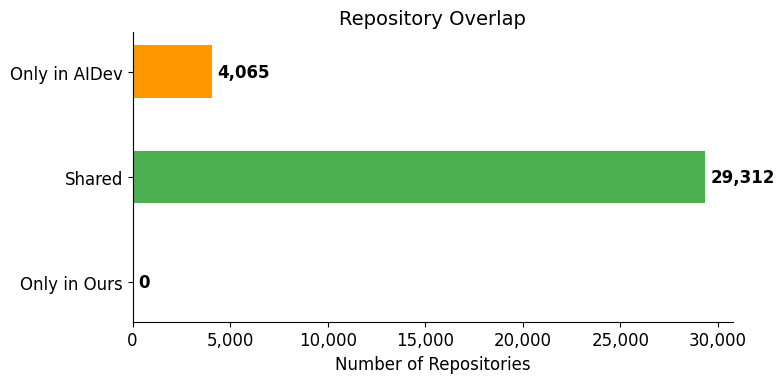

We share 87.8% of AIDev repos (29,312 / 33,377)


In [30]:
# Repository overlap
repo_data = {
    "Category": ["Only in Ours", "Shared", "Only in AIDev"],
    "Repos": [
        len(ours_repos - aidev_repos),
        len(shared_repos),
        len(aidev_repos - ours_repos)
    ]
}

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C_OURS, C_OVERLAP, C_AIDEV]
bars = ax.barh(repo_data["Category"], repo_data["Repos"], color=colors, height=0.5)
for bar, val in zip(bars, repo_data["Repos"]):
    ax.text(bar.get_width() + max(repo_data['Repos'])*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Repositories')
ax.set_title('Repository Overlap')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"We share {len(shared_repos)/len(aidev_repos)*100:.1f}% of AIDev repos ({len(shared_repos):,} / {len(aidev_repos):,})")

---
## 3. Apple-to-Apple Comparison

To make a fair comparison, we restrict **both** datasets to:
- **Same repositories** — only the repos present in both datasets
- **Same time range** — only PRs within AIDev's collection period
- **No Codex** — already excluded above
- **No human PRs in agent comparison** — human PRs compared separately

In [31]:
# ── Define the comparison scope ──
aidev_min_date = aidev["created_at"].min()
aidev_max_date = aidev["created_at"].max()
h_shared_repos = set(ours_human["repo_name"].unique()) & set(aidev_human["repo_name"].unique())

# Filter agent PRs
ours_matched = ours[
    (ours["repo_name"].isin(shared_repos)) &
    (ours["created_at"] >= aidev_min_date) &
    (ours["created_at"] <= aidev_max_date) &
    (ours["agent"] != "human")
].copy()

aidev_matched = aidev[aidev["repo_name"].isin(shared_repos)].copy()

# Filter human PRs
ours_human_matched = ours_human[
    (ours_human["repo_name"].isin(h_shared_repos)) &
    (ours_human["created_at"] >= aidev_min_date) &
    (ours_human["created_at"] <= aidev_max_date)
].copy()

aidev_human_matched = aidev_human[
    aidev_human["repo_name"].isin(h_shared_repos)
].copy()

# Build match keys for filtered data
for df in [ours_matched, aidev_matched, ours_human_matched, aidev_human_matched]:
    df["match_key"] = df["repo_name"] + "#" + df["number"].astype(str)

scope_df = pd.DataFrame({
    "Filter": ["Shared repos", "Time range", "Codex excluded", "Our agent PRs (after filter)", "AIDev agent PRs (after filter)",
               "Our human PRs (after filter)", "AIDev human PRs (after filter)"],
    "Value": [
        f"{len(shared_repos):,}",
        f"{aidev_min_date.strftime('%Y-%m-%d')}  to  {aidev_max_date.strftime('%Y-%m-%d')}",
        f"{codex_count:,} PRs removed",
        f"{len(ours_matched):,}",
        f"{len(aidev_matched):,}",
        f"{len(ours_human_matched):,}",
        f"{len(aidev_human_matched):,}",
    ]
})

display(Markdown("### Comparison Scope"))
display(scope_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

### Comparison Scope

Filter,Value
Shared repos,"29,312"
Time range,2024-12-24 to 2025-07-30
Codex excluded,"814,522 PRs removed"
Our agent PRs (after filter),"396,291"
AIDev agent PRs (after filter),"102,031"
Our human PRs (after filter),"282,239"
AIDev human PRs (after filter),"4,929"


### 3.1 Agent PR Coverage

In [32]:
# ── Compute overlap ──
m_ours_keys  = set(ours_matched["match_key"])
m_aidev_keys = set(aidev_matched["match_key"])
m_overlap    = m_ours_keys & m_aidev_keys

# ── Per-agent table ──
all_agents = sorted(set(aidev_matched["agent"].unique()) | set(ours_matched["agent"].unique()))
agent_rows = []
for ag in all_agents:
    ag_ours  = set(ours_matched[ours_matched["agent"] == ag]["match_key"]) if ag in ours_matched["agent"].values else set()
    ag_aidev = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"]) if ag in aidev_matched["agent"].values else set()
    ag_ovlp  = ag_ours & ag_aidev
    agent_rows.append({
        "Agent": ag,
        "Our PRs": len(ag_ours),
        "AIDev PRs": len(ag_aidev),
        "Overlap": len(ag_ovlp),
        "Missed": len(ag_aidev) - len(ag_ovlp),
        "We Cover AIDev": len(ag_ovlp) / len(ag_aidev) * 100 if ag_aidev else 0,
    })

# Total row
agent_rows.append({
    "Agent": "TOTAL",
    "Our PRs": len(m_ours_keys),
    "AIDev PRs": len(m_aidev_keys),
    "Overlap": len(m_overlap),
    "Missed": len(m_aidev_keys) - len(m_overlap),
    "We Cover AIDev": len(m_overlap) / len(m_aidev_keys) * 100,
})

agent_df = pd.DataFrame(agent_rows)

display(Markdown("### Agent PR Coverage (Same Repos, Same Time Range, No Codex)"))
display(
    agent_df.style
    .format({
        "Our PRs": "{:,.0f}",
        "AIDev PRs": "{:,.0f}",
        "Overlap": "{:,.0f}",
        "Missed": "{:,.0f}",
        "We Cover AIDev": "{:.1f}%",
    })
    .bar(subset=["We Cover AIDev"], color="#111F12", vmin=0, vmax=100)
    .set_properties(**{'text-align': 'right'}, subset=["Our PRs", "AIDev PRs", "Overlap", "Missed", "We Cover AIDev"])
    .set_properties(**{'text-align': 'left', 'font-weight': 'bold'}, subset=["Agent"])
    .hide(axis='index')
)

### Agent PR Coverage (Same Repos, Same Time Range, No Codex)

Agent,Our PRs,AIDev PRs,Overlap,Missed,We Cover AIDev
Claude_Code,"197,160","3,940","3,710",230,94.2%
Copilot,"59,350","44,272","44,118",154,99.7%
Cursor,"112,581","26,554","26,400",154,99.4%
Devin,"27,200","27,265","27,197",68,99.8%
TOTAL,"396,291","102,031","101,606",425,99.6%


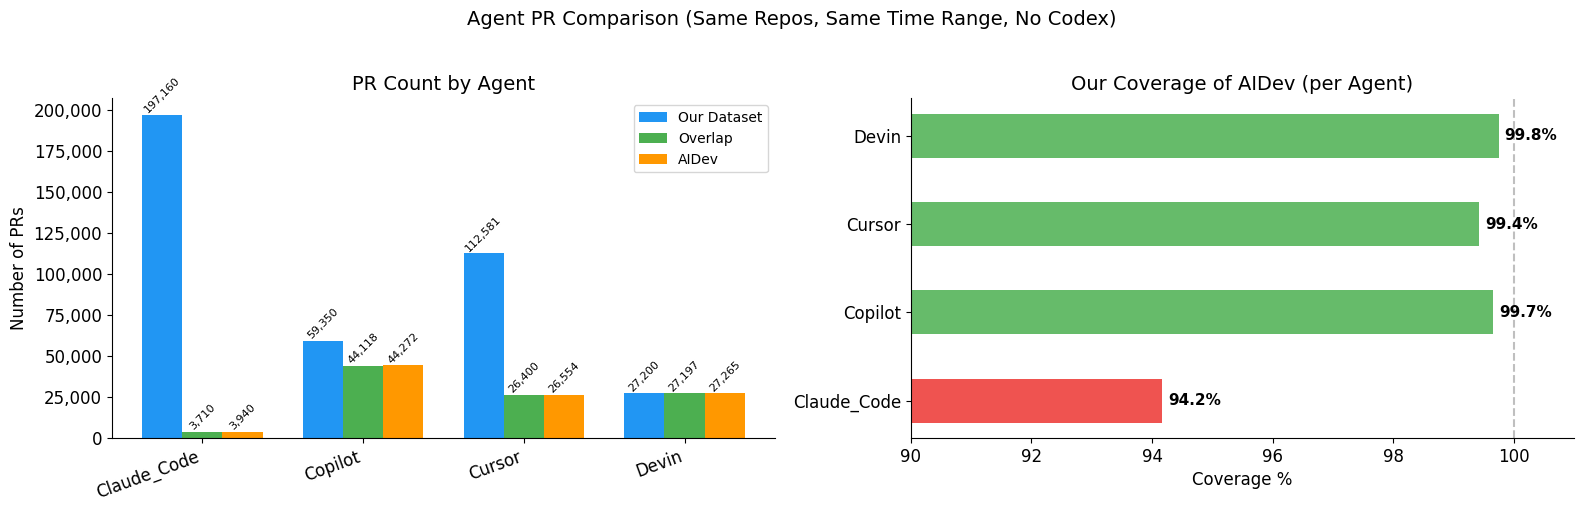

In [33]:
# ── Per-agent chart ──
agents_only = agent_df[agent_df["Agent"] != "TOTAL"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar chart
x = np.arange(len(agents_only))
w = 0.25
axes[0].bar(x - w, agents_only["Our PRs"], w, label="Our Dataset", color=C_OURS)
axes[0].bar(x,     agents_only["Overlap"], w, label="Overlap",     color=C_OVERLAP)
axes[0].bar(x + w, agents_only["AIDev PRs"], w, label="AIDev",     color=C_AIDEV)
axes[0].set_xticks(x)
axes[0].set_xticklabels(agents_only["Agent"], rotation=20, ha="right")
axes[0].set_ylabel("Number of PRs")
axes[0].set_title("PR Count by Agent")
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)

# Add value labels
for container in axes[0].containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}',
                        ha='center', va='bottom', fontsize=8, rotation=45)

# Right: coverage percentage
pct_colors = ['#66BB6A' if v >= 99 else '#FFA726' if v >= 95 else '#EF5350'
              for v in agents_only["We Cover AIDev"]]
bars = axes[1].barh(agents_only["Agent"], agents_only["We Cover AIDev"],
                    color=pct_colors, height=0.5)
axes[1].set_xlim(90, 101)
axes[1].set_xlabel("Coverage %")
axes[1].set_title("Our Coverage of AIDev (per Agent)")
axes[1].axvline(100, color='gray', linestyle='--', alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)

for bar, pct in zip(bars, agents_only["We Cover AIDev"]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.suptitle("Agent PR Comparison (Same Repos, Same Time Range, No Codex)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Human PR Coverage

In [34]:
mh_ours_keys  = set(ours_human_matched["match_key"])
mh_aidev_keys = set(aidev_human_matched["match_key"])
mh_overlap    = mh_ours_keys & mh_aidev_keys

human_df = pd.DataFrame([{
    "Category": "Human PRs",
    "Our PRs": len(mh_ours_keys),
    "AIDev PRs": len(mh_aidev_keys),
    "Overlap": len(mh_overlap),
    "Missed": len(mh_aidev_keys) - len(mh_overlap),
    "We Cover AIDev": len(mh_overlap) / len(mh_aidev_keys) * 100 if mh_aidev_keys else 0,
}])

display(Markdown("### Human PR Coverage (Same Repos, Same Time Range)"))
display(
    human_df.style
    .format({
        "Our PRs": "{:,.0f}",
        "AIDev PRs": "{:,.0f}",
        "Overlap": "{:,.0f}",
        "Missed": "{:,.0f}",
        "We Cover AIDev": "{:.1f}%",
    })
    .bar(subset=["We Cover AIDev"], color="#243B1F", vmin=0, vmax=100)
    .set_properties(**{'text-align': 'right'}, subset=["Our PRs", "AIDev PRs", "Overlap", "Missed", "We Cover AIDev"])
    .hide(axis='index')
)

### Human PR Coverage (Same Repos, Same Time Range)

Category,Our PRs,AIDev PRs,Overlap,Missed,We Cover AIDev
Human PRs,"282,239","4,929","3,799","1,130",77.1%


---
## 4. Final Summary

In [35]:
# ── Build combined summary ──
ours_agent_total  = len(m_ours_keys)
ours_human_total  = len(mh_ours_keys)
aidev_agent_total = len(m_aidev_keys)
aidev_human_total = len(mh_aidev_keys)
overlap_agent     = len(m_overlap)
overlap_human     = len(mh_overlap)

summary_rows = []

# Agent total
summary_rows.append({
    "Category": "Agent PRs",
    "Our Dataset": ours_agent_total,
    "AIDev (no Codex)": aidev_agent_total,
    "Overlap": overlap_agent,
    "We Cover AIDev %": overlap_agent / aidev_agent_total * 100,
})

# Per agent
for ag in all_agents:
    ag_o = set(ours_matched[ours_matched["agent"] == ag]["match_key"]) if ag in ours_matched["agent"].values else set()
    ag_a = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"]) if ag in aidev_matched["agent"].values else set()
    ag_v = ag_o & ag_a
    summary_rows.append({
        "Category": f"  {ag}",
        "Our Dataset": len(ag_o),
        "AIDev (no Codex)": len(ag_a),
        "Overlap": len(ag_v),
        "We Cover AIDev %": len(ag_v) / len(ag_a) * 100 if ag_a else 0,
    })

# Human
summary_rows.append({
    "Category": "Human PRs",
    "Our Dataset": ours_human_total,
    "AIDev (no Codex)": aidev_human_total,
    "Overlap": overlap_human,
    "We Cover AIDev %": overlap_human / aidev_human_total * 100 if aidev_human_total else 0,
})

# Grand total
ours_total  = ours_agent_total + ours_human_total
aidev_total = aidev_agent_total + aidev_human_total
ovlp_total  = overlap_agent + overlap_human
summary_rows.append({
    "Category": "TOTAL",
    "Our Dataset": ours_total,
    "AIDev (no Codex)": aidev_total,
    "Overlap": ovlp_total,
    "We Cover AIDev %": ovlp_total / aidev_total * 100,
})

summary = pd.DataFrame(summary_rows)

display(Markdown(f"### Final Summary  —  {len(shared_repos):,} shared repos, "
                 f"{aidev_min_date.strftime('%Y-%m-%d')} to {aidev_max_date.strftime('%Y-%m-%d')}"))
display(
    summary.style
    .format({
        "Our Dataset": "{:,.0f}",
        "AIDev (no Codex)": "{:,.0f}",
        "Overlap": "{:,.0f}",
        "We Cover AIDev %": "{:.1f}%",
    })
    .bar(subset=["We Cover AIDev %"], color="#19241A", vmin=0, vmax=100)
    .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[[0, len(summary)-2, len(summary)-1], :])
    .set_properties(**{'text-align': 'left'}, subset=["Category"])
    .set_properties(**{'text-align': 'right'}, subset=["Our Dataset", "AIDev (no Codex)", "Overlap", "We Cover AIDev %"])
    .hide(axis='index')
)

### Final Summary  —  29,312 shared repos, 2024-12-24 to 2025-07-30

Category,Our Dataset,AIDev (no Codex),Overlap,We Cover AIDev %
Agent PRs,"396,291","102,031","101,606",99.6%
Claude_Code,"197,160","3,940","3,710",94.2%
Copilot,"59,350","44,272","44,118",99.7%
Cursor,"112,581","26,554","26,400",99.4%
Devin,"27,200","27,265","27,197",99.8%
Human PRs,"282,239","4,929","3,799",77.1%
TOTAL,"678,530","106,960","105,405",98.5%


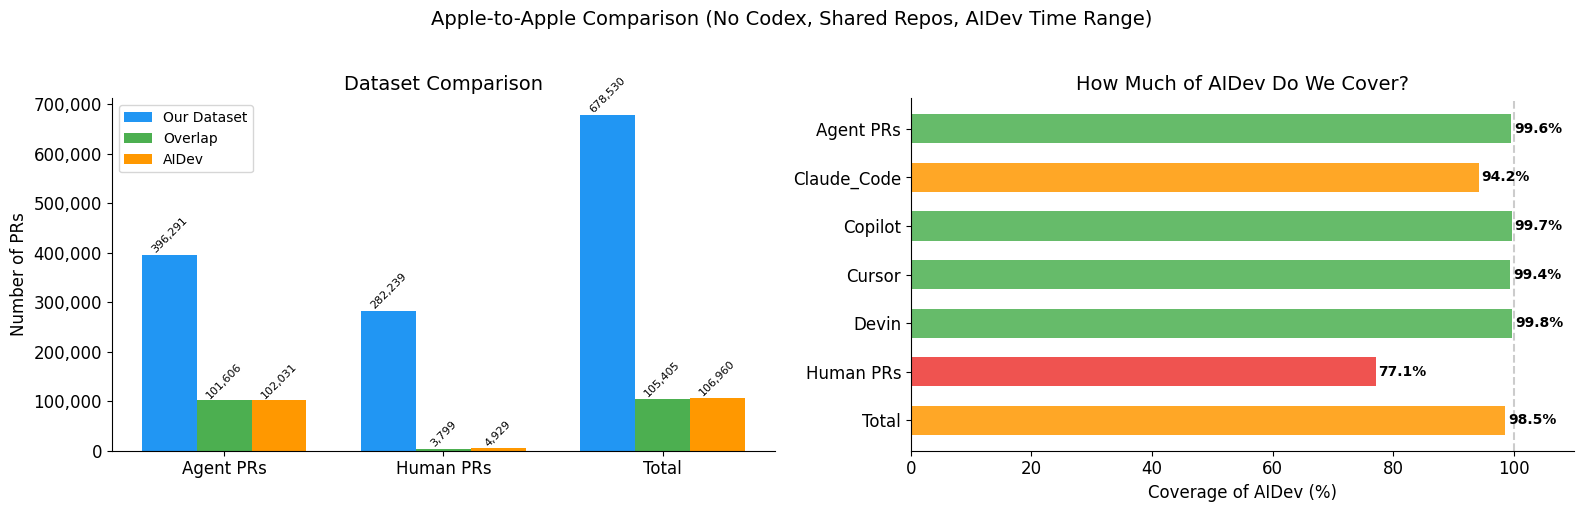

In [36]:
# ── Final visual ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Category breakdown
cats = ["Agent PRs", "Human PRs", "Total"]
ours_v = [ours_agent_total, ours_human_total, ours_total]
aidev_v = [aidev_agent_total, aidev_human_total, aidev_total]
ovlp_v = [overlap_agent, overlap_human, ovlp_total]

x = np.arange(len(cats))
w = 0.25
axes[0].bar(x - w, ours_v, w, label="Our Dataset", color=C_OURS)
axes[0].bar(x,     ovlp_v, w, label="Overlap",     color=C_OVERLAP)
axes[0].bar(x + w, aidev_v, w, label="AIDev",       color=C_AIDEV)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats)
axes[0].set_ylabel("Number of PRs")
axes[0].set_title("Dataset Comparison")
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)

for container in axes[0].containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}',
                        ha='center', va='bottom', fontsize=8, rotation=45)

# Right: Coverage gauge-style horizontal bars
cov_labels = ["Total", "Human PRs"] + list(reversed(all_agents)) + ["Agent PRs"]
cov_pcts = [
    ovlp_total / aidev_total * 100,
    overlap_human / aidev_human_total * 100 if aidev_human_total else 0,
]
for ag in reversed(all_agents):
    ag_a = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"]) if ag in aidev_matched["agent"].values else set()
    ag_o = set(ours_matched[ours_matched["agent"] == ag]["match_key"]) if ag in ours_matched["agent"].values else set()
    cov_pcts.append(len(ag_o & ag_a) / len(ag_a) * 100 if ag_a else 0)
cov_pcts.append(overlap_agent / aidev_agent_total * 100)

bar_colors = ['#66BB6A' if v >= 99 else '#FFA726' if v >= 90 else '#EF5350' for v in cov_pcts]
bars = axes[1].barh(cov_labels, cov_pcts, color=bar_colors, height=0.6)
axes[1].set_xlim(0, 110)
axes[1].axvline(100, color='gray', linestyle='--', alpha=0.4)
axes[1].set_xlabel("Coverage of AIDev (%)")
axes[1].set_title("How Much of AIDev Do We Cover?")
axes[1].spines[['top', 'right']].set_visible(False)

for bar, pct in zip(bars, cov_pcts):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.suptitle("Apple-to-Apple Comparison (No Codex, Shared Repos, AIDev Time Range)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. What's Different & Why

Brief analysis of the small number of PRs that differ between the datasets.

In [37]:
m_aidev_only  = m_aidev_keys - m_ours_keys
m_ours_only   = m_ours_keys  - m_aidev_keys

aidev_only_matched = aidev_matched[aidev_matched["match_key"].isin(m_aidev_only)]
ours_only_matched  = ours_matched[ours_matched["match_key"].isin(m_ours_only)]

# ── AIDev PRs we missed ──
missed_by_agent = aidev_only_matched["agent"].value_counts().reset_index()
missed_by_agent.columns = ["Agent", "Missed PRs"]

# ── Our extra PRs ──
extra_by_agent = ours_only_matched["agent"].value_counts().reset_index()
extra_by_agent.columns = ["Agent", "Extra PRs"]

display(Markdown(f"### AIDev Agent PRs We Missed: {len(m_aidev_only):,}"))
display(missed_by_agent.style.format({"Missed PRs": "{:,.0f}"}).hide(axis='index'))

missed_repos_we_have = set(aidev_only_matched["repo_name"]) & set(ours_matched["repo_name"])
missed_repos_we_dont = set(aidev_only_matched["repo_name"]) - set(ours_matched["repo_name"])

display(Markdown(
    f"- Repos where we have *some* PRs but missed these: **{len(missed_repos_we_have):,}**\n"
    f"- Repos where we have *no* agent PRs at all: **{len(missed_repos_we_dont):,}**"
))

display(Markdown(f"### Our Agent PRs Not in AIDev: {len(m_ours_only):,}"))
display(extra_by_agent.style.format({"Extra PRs": "{:,.0f}"}).hide(axis='index'))

display(Markdown(
    "**Likely reasons:**\n"
    "- We collect all PRs (`state=all`) then classify agents; AIDev may filter differently\n"
    "- Different agent detection heuristics (username vs commit signature vs bot label)\n"
    "- PR state changes between collection times"
))

### AIDev Agent PRs We Missed: 425

Agent,Missed PRs
Cursor,152
Copilot,128
Claude_Code,77
Devin,68


- Repos where we have *some* PRs but missed these: **57**
- Repos where we have *no* agent PRs at all: **79**

### Our Agent PRs Not in AIDev: 294,685

Agent,Extra PRs
Claude_Code,"193,450"
Cursor,"86,010"
Copilot,"15,224"
Devin,1


**Likely reasons:**
- We collect all PRs (`state=all`) then classify agents; AIDev may filter differently
- Different agent detection heuristics (username vs commit signature vs bot label)
- PR state changes between collection times

---
## Key Takeaways

1. **Our dataset covers 99.6% of AIDev's agent PRs** (same repos, same time range, no Codex)
2. **Per-agent coverage is 94-100%** across all four agents (Devin 99.8%, Copilot 99.7%, Cursor 99.4%, Claude Code 94.2%)
3. **Our dataset is substantially larger** — we have ~4x more agent PRs in the matched scope (396K vs 102K), particularly for Claude Code
4. **Only 425 AIDev agent PRs are missing** from our collection, spread across 136 repos
5. **Agent label agreement is high** across the overlapping PRs